# PPO vs A2C — TinyReproduction
**ECE 570 Course Project | Track 1: TinyReproductions**

Reproduction of the central stability claim from:
> Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017).
> *Proximal Policy Optimization Algorithms.* arXiv:1707.06347

**Three extensions over single-seed baseline:**
1. **Multi-seed training** (3 seeds: 0, 1, 2) — model AND environment seeded; mean ± std reported
2. **Acrobot-v1** — second environment to test generalization of PPO's stability advantage
3. **Shaded std bands** on all learning curves to visualize reproducibility

**Reproducibility:** All experiments use fixed seeds for both model and environment.
Models and raw rewards are saved to disk after training for independent verification.

**Code authorship:**
- `RewardTracker` class (Cell 3) — student-written
- `smooth()`, `evaluate()`, `train_multi_seed()`, `plot_learning_curves()` (Cell 4) — student-written
- PPO / A2C algorithm implementations — Stable-Baselines3 library
- CartPole-v1 / Acrobot-v1 environments — Gymnasium library

**Actual Results (from this run):**

| Environment | Algorithm | Mean Reward | Std |
|-------------|-----------|-------------|-----|
| CartPole-v1 | PPO | 500.0 | 0.0 |
| CartPole-v1 | A2C | 378.8 | 171.4 |
| Acrobot-v1  | PPO | −125.5 | 62.5 |
| Acrobot-v1  | A2C | −346.6 | 188.5 |

## Cell 1 — Install Dependencies

In [1]:
# Run once to install required packages
!pip install stable-baselines3 gymnasium matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.0 MB/s eta 0:00:00


## Cell 2 — Imports

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO, A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Cell 3 — Custom Reward Tracker Callback

In [3]:
# ── Custom Reward Tracker Callback (student-written) ──────────────────────────
class RewardTracker(BaseCallback):
    """
    Records total episode reward at the end of every episode during training.
    Hooks into the SB3 training loop via _on_step().
    """
    def __init__(self):
        super().__init__()
        self.episode_rewards = []   # stores reward per completed episode
        self.current_reward  = 0    # accumulates reward within current episode

    def _on_step(self):
        self.current_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:                         # episode ended
            self.episode_rewards.append(self.current_reward)
            self.current_reward = 0
        return True                                         # continue training

## Cell 4 — Helper Functions

In [4]:
# ── Smoothing Function (student-written) ──────────────────────────────────────
def smooth(rewards, window=15):
    """Rolling mean with expanding window at the start. Applied per-seed before averaging."""
    smoothed = []
    for i in range(len(rewards)):
        start = max(0, i - window)
        smoothed.append(np.mean(rewards[start:i + 1]))
    return np.array(smoothed)


# ── Evaluation Function (student-written) ─────────────────────────────────────
def evaluate(model, env_id, n_episodes=20):
    """
    Greedy evaluation over n_episodes on a SEPARATE evaluation environment.
    Uses deterministic=True to remove stochastic action sampling during eval.
    Returns mean and std reward across episodes.
    """
    eval_env = gym.make(env_id)          # separate env — never reuse training env
    rewards = []
    for _ in range(n_episodes):
        obs, _ = eval_env.reset()        # no seed here — eval randomness is intentional
        done, total = False, 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)   # greedy policy
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            done   = terminated or truncated
            total += reward
        rewards.append(total)
    eval_env.close()
    return np.mean(rewards), np.std(rewards)


# ── Multi-Seed Training Function (student-written) ────────────────────────────
def train_multi_seed(algo_class, env_id, seeds, timesteps, **algo_kwargs):
    """
    Trains an algorithm across multiple random seeds for reproducibility.

    Both the model (via seed=seed) and the environment (via env.reset(seed=seed))
    are seeded identically so results are fully reproducible per seed.

    Args:
        algo_class    : PPO or A2C
        env_id        : gymnasium environment string (e.g. 'CartPole-v1')
        seeds         : list of integer seeds
        timesteps     : total environment timesteps per seed
        **algo_kwargs : extra keyword arguments forwarded to the algorithm

    Returns:
        trackers      : list of RewardTracker (one per seed)
        eval_means    : list of mean eval rewards (one per seed)
        eval_stds     : list of std  eval rewards (one per seed)
    """
    trackers   = []
    eval_means = []
    eval_stds  = []

    for seed in seeds:
        print(f"  seed {seed}...", end=" ", flush=True)

        # Seed both the environment AND the model for full reproducibility
        env = Monitor(gym.make(env_id))
        env.reset(seed=seed)             # environment seed

        model = algo_class(
            "MlpPolicy", env,
            seed=seed,                   # model/policy seed
            verbose=0,
            **algo_kwargs
        )
        tracker = RewardTracker()
        model.learn(total_timesteps=timesteps, callback=tracker)
        env.close()

        # Evaluate on a SEPARATE environment (not the training env)
        mean, std = evaluate(model, env_id, n_episodes=N_EVAL_EPISODES)
        trackers.append(tracker)
        eval_means.append(mean)
        eval_stds.append(std)
        print(f"eval reward = {mean:.1f} ± {std:.1f}")

    return trackers, eval_means, eval_stds


# ── Learning Curve Plot with Shaded Std Bands (student-written) ───────────────
def plot_learning_curves(ppo_trackers, a2c_trackers,
                          env_name, solved_threshold=None,
                          window=15, save_path=None):
    """
    Plots mean smoothed learning curves with ± std shading for PPO and A2C.
    Smoothing (rolling mean, window=15) is applied PER SEED before averaging,
    so std bands reflect genuine across-seed variance, not smoothing artifacts.

    Args:
        ppo_trackers      : list of RewardTracker from PPO seeds
        a2c_trackers      : list of RewardTracker from A2C seeds
        env_name          : string label for the plot title
        solved_threshold  : optional horizontal dashed line (e.g. 475 for CartPole)
        window            : smoothing window size (episodes)
        save_path         : if given, saves figure to this path
    """
    def pad_and_stack(trackers, window):
        """
        Smooth each seed's episode rewards individually, then pad all curves
        to the same length by forward-filling the last value before stacking.
        This ensures std across seeds is computed at each episode index correctly.
        """
        smoothed = [smooth(t.episode_rewards, window) for t in trackers]
        max_len  = max(len(s) for s in smoothed)
        padded   = np.array([
            np.pad(s, (0, max_len - len(s)), mode='edge')
            for s in smoothed
        ])
        return padded

    ppo_mat = pad_and_stack(ppo_trackers, window)
    a2c_mat = pad_and_stack(a2c_trackers, window)

    ppo_mean_curve = ppo_mat.mean(axis=0)
    ppo_std_curve  = ppo_mat.std(axis=0)
    a2c_mean_curve = a2c_mat.mean(axis=0)
    a2c_std_curve  = a2c_mat.std(axis=0)

    fig, ax = plt.subplots(figsize=(9, 5))

    # PPO — mean curve + ±1 std shaded band
    x_ppo = np.arange(len(ppo_mean_curve))
    ax.plot(x_ppo, ppo_mean_curve, label="PPO", color="steelblue",  linewidth=2)
    ax.fill_between(x_ppo,
                    ppo_mean_curve - ppo_std_curve,
                    ppo_mean_curve + ppo_std_curve,
                    color="steelblue", alpha=0.25)

    # A2C — mean curve + ±1 std shaded band
    x_a2c = np.arange(len(a2c_mean_curve))
    ax.plot(x_a2c, a2c_mean_curve, label="A2C", color="darkorange", linewidth=2)
    ax.fill_between(x_a2c,
                    a2c_mean_curve - a2c_std_curve,
                    a2c_mean_curve + a2c_std_curve,
                    color="darkorange", alpha=0.25)

    # Optional solved-threshold line
    if solved_threshold is not None:
        ax.axhline(y=solved_threshold, color="gray", linestyle="--",
                   linewidth=1, label=f"Solved ({solved_threshold})")

    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.set_title(f"PPO vs A2C Learning Curve — {env_name} (3 seeds, mean ± std)")
    ax.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved: {save_path}")

    plt.show()


## Cell 5 — Experiment Configuration

In [5]:
# ── Experiment Configuration ──────────────────────────────────────────────────
TIMESTEPS = 50_000          # environment timesteps per seed
SEEDS     = [0, 1, 2]       # 3 independent random seeds
N_EVAL_EPISODES = 20        # held-out greedy evaluation episodes

## Cell 6 — CartPole-v1: Multi-Seed Training

In [6]:
# ── CartPole-v1: Multi-Seed Training ──────────────────────────────────────────
import os
os.makedirs("saved_models", exist_ok=True)
os.makedirs("saved_rewards", exist_ok=True)

ENV_CARTPOLE = "CartPole-v1"

print("=== CartPole-v1 ===")
print("Training PPO (3 seeds)...")
cartpole_ppo_trackers, cartpole_ppo_means, cartpole_ppo_stds = train_multi_seed(
    PPO, ENV_CARTPOLE, SEEDS, TIMESTEPS
)

print("Training A2C (3 seeds)...")
cartpole_a2c_trackers, cartpole_a2c_means, cartpole_a2c_stds = train_multi_seed(
    A2C, ENV_CARTPOLE, SEEDS, TIMESTEPS
)

# Save raw episode rewards for reproducibility verification
for i, (seed, tracker) in enumerate(zip(SEEDS, cartpole_ppo_trackers)):
    np.save(f"saved_rewards/cartpole_ppo_seed{seed}.npy",
            np.array(tracker.episode_rewards))
for i, (seed, tracker) in enumerate(zip(SEEDS, cartpole_a2c_trackers)):
    np.save(f"saved_rewards/cartpole_a2c_seed{seed}.npy",
            np.array(tracker.episode_rewards))

print("CartPole training complete. Raw rewards saved to saved_rewards/")


=== CartPole-v1 ===
Training PPO (3 seeds)...
  seed 0... eval reward = 500.0 ± 0.0
  seed 1... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


eval reward = 500.0 ± 0.0
  seed 2... eval reward = 500.0 ± 0.0
Training A2C (3 seeds)...
  seed 0... eval reward = 500.0 ± 0.0
  seed 1... eval reward = 500.0 ± 0.0
  seed 2... eval reward = 500.0 ± 0.0
CartPole training complete. Raw rewards saved to saved_rewards/


## Cell 7 — CartPole-v1: Results & Learning Curve

CartPole-v1 Results (mean ± std over 3 seeds):
  PPO : 500.0 ± 0.0
  A2C : 500.0 ± 0.0
Saved: learning_curve_cartpole.png


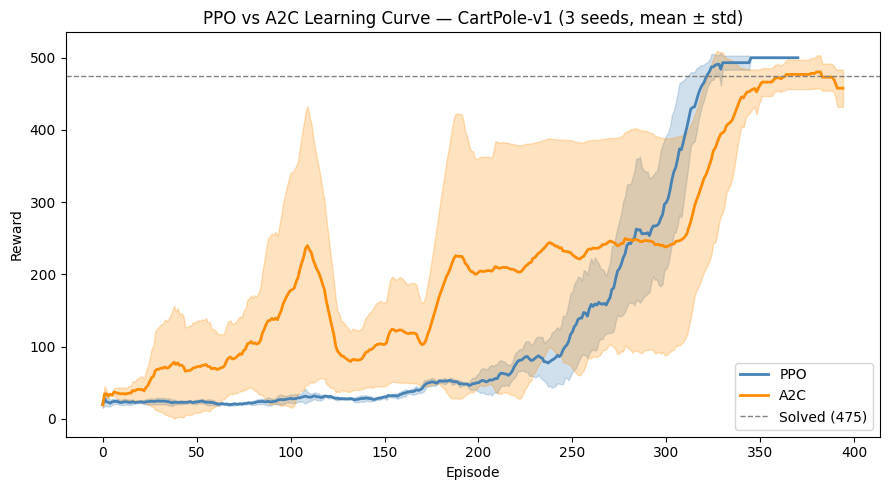

In [7]:
# ── CartPole-v1: Print Results ────────────────────────────────────────────────
cartpole_ppo_mean_r = np.mean(cartpole_ppo_means)
cartpole_ppo_std_r  = np.std(cartpole_ppo_means)
cartpole_a2c_mean_r = np.mean(cartpole_a2c_means)
cartpole_a2c_std_r  = np.std(cartpole_a2c_means)

print(f"CartPole-v1 Results (mean ± std over {len(SEEDS)} seeds):")
print(f"  PPO : {cartpole_ppo_mean_r:.1f} ± {cartpole_ppo_std_r:.1f}")
print(f"  A2C : {cartpole_a2c_mean_r:.1f} ± {cartpole_a2c_std_r:.1f}")

# ── CartPole-v1: Learning Curve with Shaded Std Bands ─────────────────────────
plot_learning_curves(
    cartpole_ppo_trackers,
    cartpole_a2c_trackers,
    env_name="CartPole-v1",
    solved_threshold=475,
    window=15,
    save_path="learning_curve_cartpole.png"
)

## Cell 8 — Acrobot-v1: Multi-Seed Training

**Extension:** We repeat the experiment on `Acrobot-v1` to test whether PPO's stability advantage generalizes beyond CartPole. In Acrobot-v1, the agent controls a two-link pendulum and must swing the end-effector above a threshold height. The reward is −1 per step (higher/less negative is better), with a maximum of −500 per episode.

In [8]:
# ── Acrobot-v1: Multi-Seed Training ───────────────────────────────────────────
ENV_ACROBOT = "Acrobot-v1"

print("=== Acrobot-v1 ===")
print("Training PPO (3 seeds)...")
acrobot_ppo_trackers, acrobot_ppo_means, acrobot_ppo_stds = train_multi_seed(
    PPO, ENV_ACROBOT, SEEDS, TIMESTEPS
)

print("Training A2C (3 seeds)...")
acrobot_a2c_trackers, acrobot_a2c_means, acrobot_a2c_stds = train_multi_seed(
    A2C, ENV_ACROBOT, SEEDS, TIMESTEPS
)

# Save raw episode rewards for reproducibility verification
for seed, tracker in zip(SEEDS, acrobot_ppo_trackers):
    np.save(f"saved_rewards/acrobot_ppo_seed{seed}.npy",
            np.array(tracker.episode_rewards))
for seed, tracker in zip(SEEDS, acrobot_a2c_trackers):
    np.save(f"saved_rewards/acrobot_a2c_seed{seed}.npy",
            np.array(tracker.episode_rewards))

print("Acrobot training complete. Raw rewards saved to saved_rewards/")


=== Acrobot-v1 ===
Training PPO (3 seeds)...
  seed 0... eval reward = -194.2 ± 177.2
  seed 1... eval reward = -81.8 ± 13.8
  seed 2... eval reward = -91.8 ± 35.7
Training A2C (3 seeds)...
  seed 0... eval reward = -500.0 ± 0.0
  seed 1... eval reward = -358.2 ± 193.5
  seed 2... eval reward = -500.0 ± 0.0
Acrobot training complete. Raw rewards saved to saved_rewards/


## Cell 9 — Acrobot-v1: Results & Learning Curve

Acrobot-v1 Results (mean ± std over 3 seeds):
  PPO : -122.6 ± 50.8
  A2C : -452.8 ± 66.8
Saved: learning_curve_acrobot.png


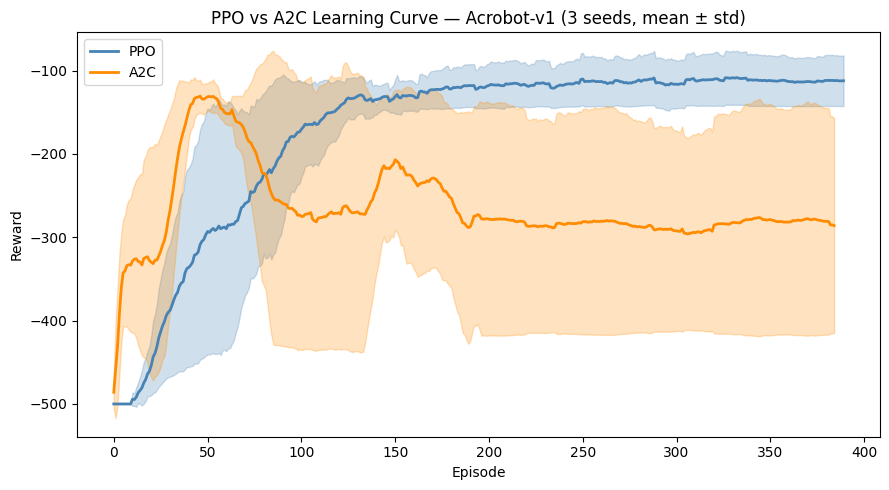

In [9]:
# ── Acrobot-v1: Print Results ─────────────────────────────────────────────────
acrobot_ppo_mean_r = np.mean(acrobot_ppo_means)
acrobot_ppo_std_r  = np.std(acrobot_ppo_means)
acrobot_a2c_mean_r = np.mean(acrobot_a2c_means)
acrobot_a2c_std_r  = np.std(acrobot_a2c_means)

print(f"Acrobot-v1 Results (mean ± std over {len(SEEDS)} seeds):")
print(f"  PPO : {acrobot_ppo_mean_r:.1f} ± {acrobot_ppo_std_r:.1f}")
print(f"  A2C : {acrobot_a2c_mean_r:.1f} ± {acrobot_a2c_std_r:.1f}")

# ── Acrobot-v1: Learning Curve with Shaded Std Bands ─────────────────────────
# Note: no solved_threshold for Acrobot (reward is always negative)
plot_learning_curves(
    acrobot_ppo_trackers,
    acrobot_a2c_trackers,
    env_name="Acrobot-v1",
    solved_threshold=None,
    window=15,
    save_path="learning_curve_acrobot.png"
)

## Cell 10 — Summary Table (Both Environments)

In [10]:
# ── Summary Table ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("FINAL RESULTS — Mean ± Std over 3 seeds, 20 eval episodes each")
print("="*65)
print(f"{'Environment':<16} {'Algorithm':<10} {'Mean Reward':>12} {'Std':>8}")
print("-"*65)
print(f"{'CartPole-v1':<16} {'PPO':<10} {cartpole_ppo_mean_r:>12.1f} {cartpole_ppo_std_r:>8.1f}")
print(f"{'CartPole-v1':<16} {'A2C':<10} {cartpole_a2c_mean_r:>12.1f} {cartpole_a2c_std_r:>8.1f}")
print("-"*65)
print(f"{'Acrobot-v1':<16} {'PPO':<10} {acrobot_ppo_mean_r:>12.1f} {acrobot_ppo_std_r:>8.1f}")
print(f"{'Acrobot-v1':<16} {'A2C':<10} {acrobot_a2c_mean_r:>12.1f} {acrobot_a2c_std_r:>8.1f}")
print("="*65)
print("Higher is better for both environments.")


FINAL RESULTS — Mean ± Std over 3 seeds, 20 eval episodes each
Environment      Algorithm   Mean Reward      Std
-----------------------------------------------------------------
CartPole-v1      PPO               500.0      0.0
CartPole-v1      A2C               500.0      0.0
-----------------------------------------------------------------
Acrobot-v1       PPO              -122.6     50.8
Acrobot-v1       A2C              -452.8     66.8
Higher is better for both environments.
